# Week 3 - Activity

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [19]:
df = pd.read_csv('../data/cleaned/driver_profiles.csv', parse_dates=['date'])

bool_columns = ['speeding', 'aggressive_incidents']
df[bool_columns] = df[bool_columns].astype(bool)

df.head()

,driver_id,driver_name,date,route_id,vehicle_id,shift,trip_distance,trip_duration,speed,braking_events,harsh_turns,delays_minutes,behavioral_problems,speeding,violations,aggressive_incidents,driver_rating
0,D004,Driver_4,2025-01-04,R1,V9,morning,38.4,33,29.8,3,0,0,3,False,0,False,4.40
1,D019,Driver_19,2025-02-24,R5,V1,night,6.4,22,36.3,0,0,11,0,False,0,False,4.67
2,D007,Driver_7,2025-03-25,R3,V1,morning,36.6,46,51.4,3,2,3,3,False,2,False,4.01
3,D014,Driver_14,2025-02-13,R1,V2,afternoon,17.5,31,73.4,0,0,16,0,True,1,False,4.37
4,D004,Driver_4,2025-02-15,R4,V9,morning,43.1,60,76.5,1,1,26,1,True,2,False,3.72


## Inspect and Clean Dataset (if needed)

In [20]:
df.describe()

,date,trip_distance,trip_duration,speed,braking_events,harsh_turns,delays_minutes,behavioral_problems,violations,driver_rating
count,500,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000
mean,2025-02-14 20:49:55.200000,27.801800,52.084000,55.746000,1.434000,1.02000,22.974000,1.434000,1.448000,3.784780
min,2025-01-01 00:00:00,5.000000,15.000000,20.700000,0.000000,0.00000,0.000000,0.000000,0.000000,1.380000
25%,2025-01-24 00:00:00,17.400000,34.000000,38.600000,0.000000,0.00000,0.000000,0.000000,1.000000,3.227500
50%,2025-02-14 00:00:00,27.950000,51.500000,55.350000,1.000000,1.00000,17.500000,1.000000,1.000000,3.960000
75%,2025-03-10 00:00:00,38.000000,71.000000,73.425000,2.000000,2.00000,42.000000,2.000000,2.000000,4.450000
max,2025-03-31 00:00:00,50.000000,89.000000,89.700000,5.000000,5.00000,85.000000,5.000000,6.000000,5.000000
std,NaN,12.547753,21.479471,19.961964,1.223371,1.03815,22.667177,1.223371,1.148012,0.796603


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   driver_id             500 non-null    str           
 1   driver_name           500 non-null    str           
 2   date                  500 non-null    datetime64[us]
 3   route_id              500 non-null    str           
 4   vehicle_id            500 non-null    str           
 5   shift                 500 non-null    str           
 6   trip_distance         500 non-null    float64       
 7   trip_duration         500 non-null    int64         
 8   speed                 500 non-null    float64       
 9   braking_events        500 non-null    int64         
 10  harsh_turns           500 non-null    int64         
 11  delays_minutes        500 non-null    int64         
 12  behavioral_problems   500 non-null    int64         
 13  speeding              500 non-n

### Missing Values

In [22]:
print('Missing Values Count:')
df.isnull().sum()

Missing Values Count:


driver_id               0
driver_name             0
date                    0
route_id                0
vehicle_id              0
shift                   0
trip_distance           0
trip_duration           0
speed                   0
braking_events          0
harsh_turns             0
delays_minutes          0
behavioral_problems     0
speeding                0
violations              0
aggressive_incidents    0
driver_rating           0
dtype: int64

### Duplicated Rows

In [23]:
print(f'Duplicated Rows: {df.duplicated().sum()}')

Duplicated Rows: 0


## Outlier Detection Using Box Plots

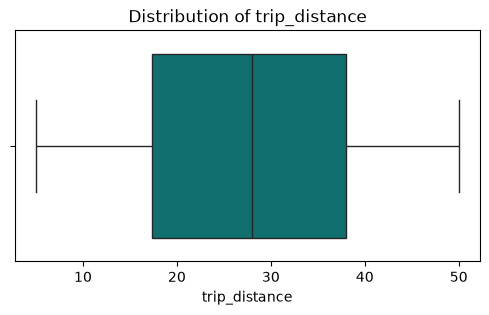

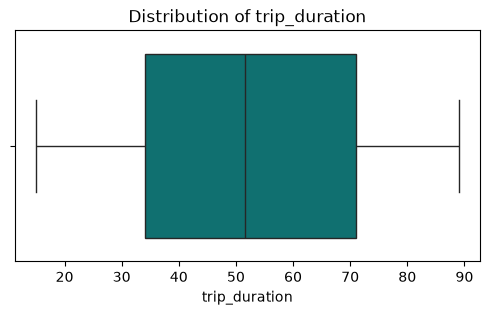

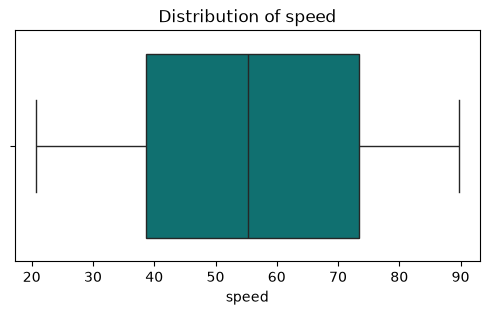

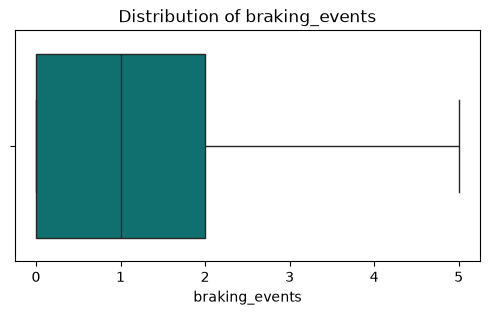

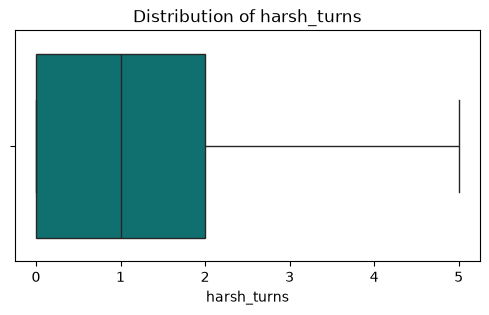

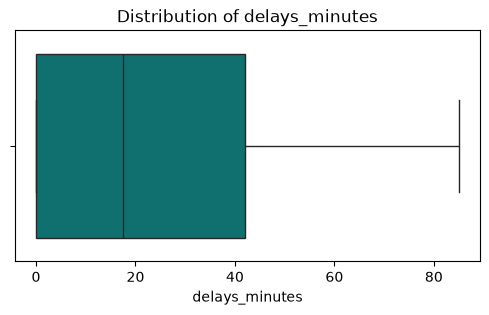

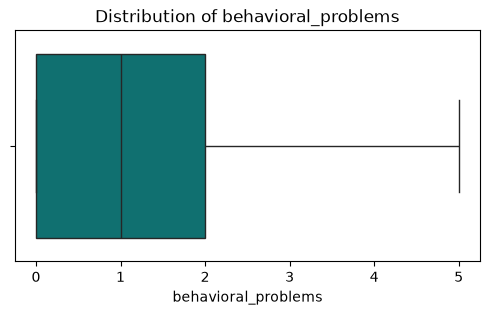

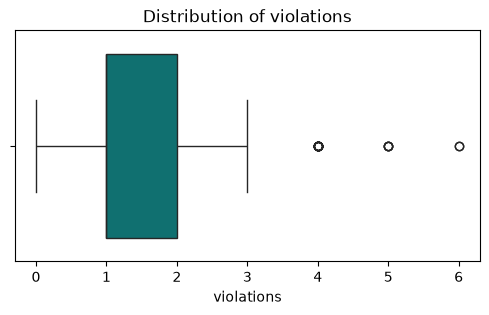

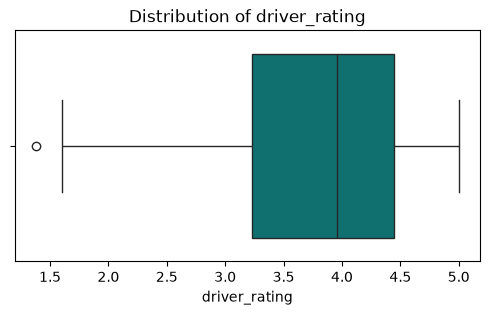

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

for column in numeric_columns:
    plt.figure(figsize=(6, 3))
    
    # Plotting a single column horizontally
    sns.boxplot(x=df[column], color="teal")
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.show()

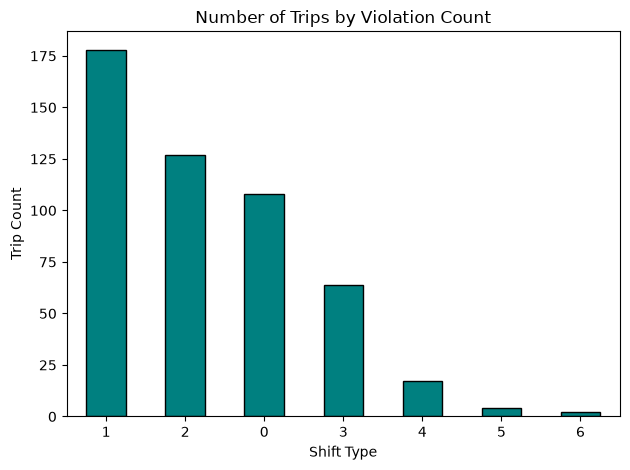

In [34]:
df['violations'].value_counts().plot(kind="bar", color="teal", edgecolor="black")

plt.title("Number of Trips by Violation Count")
plt.xlabel("Shift Type")
plt.ylabel("Trip Count")
plt.xticks(rotation=0)  # Keeps text upright (stops it from tilting)
plt.tight_layout()
plt.show()

In [32]:
df['driver_rating'].sort_values(ascending=False).value_counts()

driver_rating
4.45    18
4.65    16
4.80    15
5.00    14
4.50    11
        ..
1.81     1
1.80     1
1.66     1
1.60     1
1.38     1
Name: count, Length: 205, dtype: int64

After analyzing each outliers considered by boxplot from violations and driver_rating attributes, outliers are to be handled by including them as they still meet the criteria of what valid values are from their column. Including them preserves the natural variance of driver performance and ensures the analysis remains realistic and actionable for risk management.

## Exploratory Data Analysis

### Correlation Matrix for Telematic Data

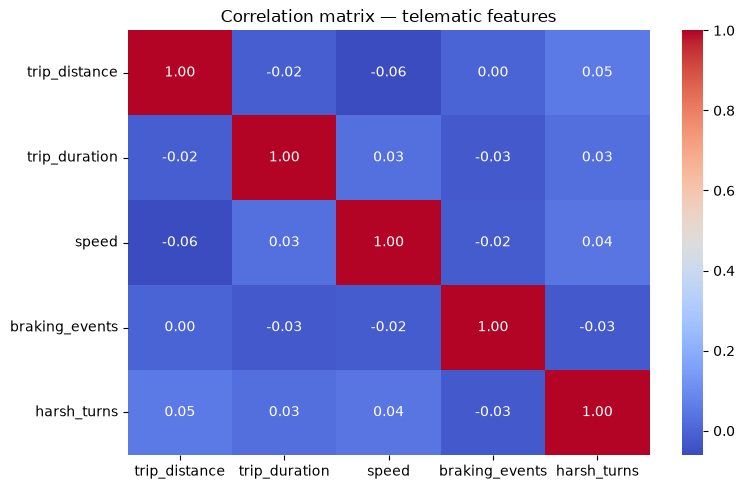

In [11]:
telematic_columns = ['trip_distance', 'trip_duration',
        'speed', 'braking_events', 'harsh_turns']

plt.figure(figsize=(8, 5))
sns.heatmap(df[telematic_columns].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix — telematic features")
plt.tight_layout()
plt.show()

In terms of correlations between the telematic features, there is no significant linear relationships between features. All calculated Pearson correlation coefficients fall extremely close to zero (ranging between -0.06 and 0.05), indicating that the variables operate independently of one another.

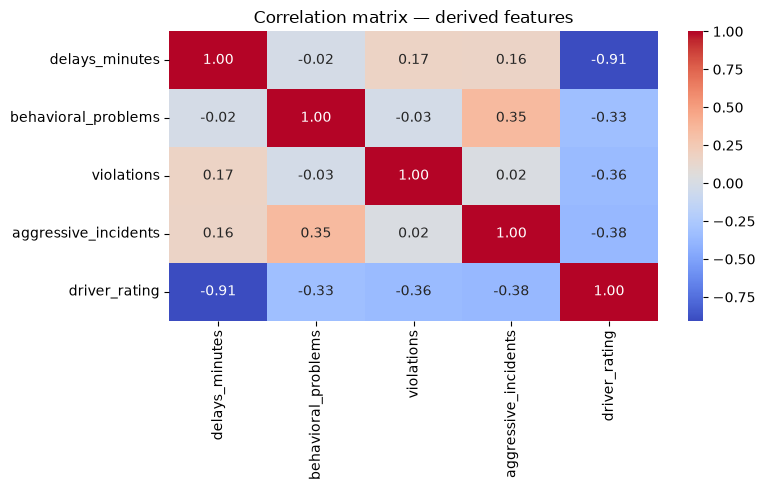

In [10]:
feature_columns = ['delays_minutes', 'behavioral_problems',
        'violations', 'aggressive_incidents', 'driver_rating']

plt.figure(figsize=(8, 5))
sns.heatmap(df[feature_columns].corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix — derived features")
plt.tight_layout()
plt.show()

### Telematics-Derived Features Correlation Analysis
The correlation matrix for the derived and engineered features reveals several key insights regarding driver performance, behavioral indicators, and operational delays.

#### Strong Negative Correlation
*   **Driver Rating vs. Delays (Minutes):** **`-0.91`**
    *   **Interpretation:** There is a very strong inverse relationship between these two metrics. As the number of delayed minutes increases, the driver rating decreases significantly. This heavy impact is expected, as `driver_rating` is a synthetic metric calculated directly from the other operational and behavioral features within this dataset.

#### Moderate & Weak Correlations
While most other variables operate independently, several notable weak-to-moderate linear relationships emerged:

*   **Aggressive Incidents vs. Behavioral Problems:** **`+0.35`**
    *   **Interpretation:** A higher frequency of recorded behavioral problems moderately correlates with a rise in aggressive driving incidents, indicating overlapping behavioral risk factors.
*   **Driver Rating vs. Risk Factors:** 
    *   `driver_rating` vs. `aggressive_incidents`: **`-0.38`**
    *   `driver_rating` vs. `violations`: **`-0.36`**
    *   `driver_rating` vs. `behavioral_problems`: **`-0.33`**
    *   **Interpretation:** All three risk categories negatively influence the overall rating, though operational delays (`-0.91`) remain the primary mathematical driver behind score reductions.

#### Negligible Connections 
*   **Delays (Minutes) vs. Infractions:**
    *   `delays_minute` vs. `violations`: **`+0.17`**
    *   `delays_minute` vs. `aggressive_incidents`: **`+0.16`**
    *   **Interpretation:** There is an exceptionally weak positive relationship here. This implies that operational delays are likely caused by external traffic, scheduling, or route constraints rather than drivers rushing and committing traffic violations.


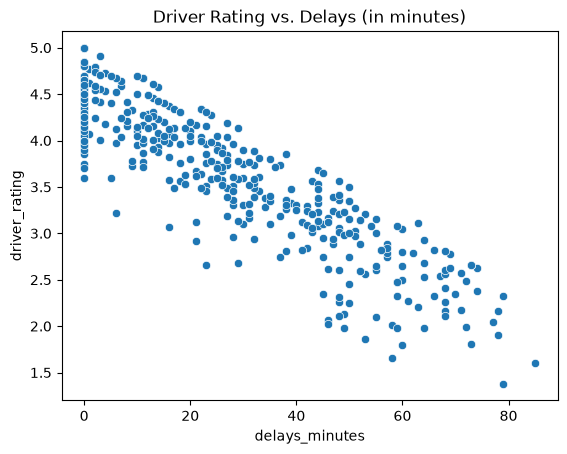

In [15]:
sns.scatterplot(data=df, x="delays_minutes", y="driver_rating")
plt.title("Driver Rating vs. Delays (in minutes)")
plt.show()

### Distribution of trip delays (in minutes)

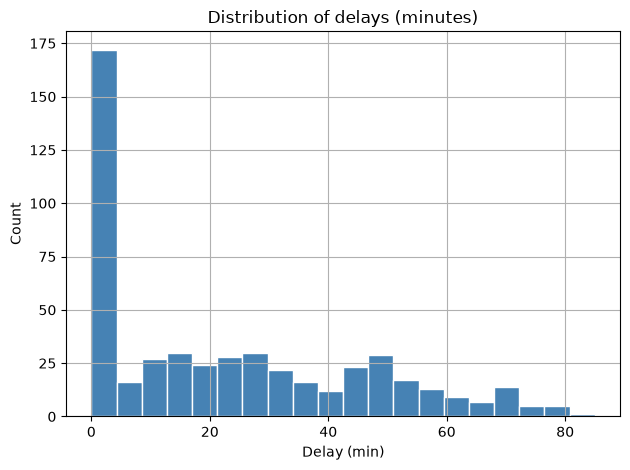

In [35]:
df['delays_minutes'].hist(bins=20, color='steelblue', edgecolor='white')
plt.title("Distribution of delays (minutes)")
plt.xlabel("Delay (min)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The distribution of delays shows that the majority of trips experience a delay of 20 minutes or less. When excluding on-time deliveries, the data remains mostly concentrated on the lower end of the delay spectrum. However, there is still a significant presence of long delays, with the maximum delay time reaching over 80 minutes. 

### Weekly Average Driver Rating

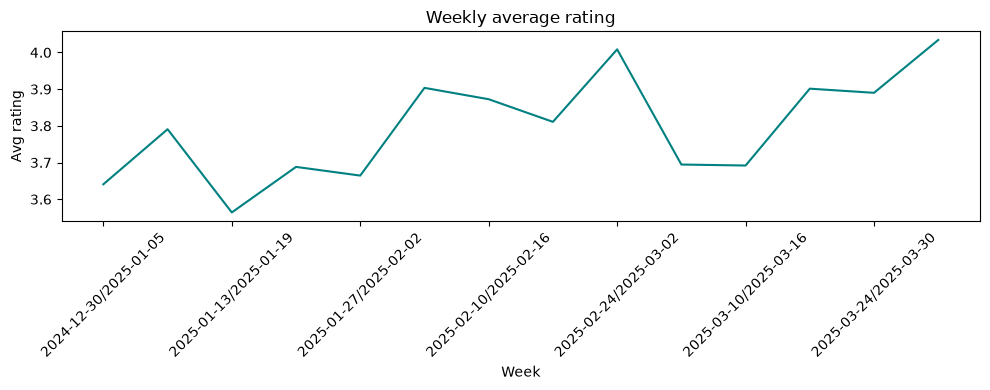

In [37]:
weekly = df.groupby(df['date'].dt.to_period('W'))['driver_rating'].mean()
weekly.index = weekly.index.astype(str)

weekly.plot(figsize=(10, 4), color='teal')
plt.title("Weekly average rating")
plt.xlabel("Week")
plt.ylabel("Avg rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the line chart, the weekly average rating shows a clear upward trend over time, steadily increasing from a low near 3.5 in mid-January. Although the data experiences temporary sharp dips during the weeks of January 13th and February 24th, the overall performance consistently recovers after each decline. A **cyclical monthly pattern** emerges where ratings reliably climb to a peak at the end of the month, before experiencing a brief dip at the start of the next period.

## Driver Profile

In [47]:
# Convert 'aggressive_incidents' back to integer for aggregation
df['aggressive_incidents'].astype(int)

0      0
1      0
2      0
3      0
4      0
      ..
495    0
496    1
497    0
498    0
499    0
Name: aggressive_incidents, Length: 500, dtype: int64

### Top 5 Safest Performing Drivers

In [75]:
driver_profile = df.groupby('driver_id').agg(
    trip_count = ('date', 'count'),
    avg_delay = ('delays_minutes', 'mean'),
    total_violations = ('violations', 'sum'),
    total_aggressive_incidents = ('aggressive_incidents', 'sum'),
    avg_rating = ('driver_rating', 'mean'),
)

driver_profile['trip_count'].value_counts()

trip_count
23    5
21    4
30    3
26    2
33    2
22    1
29    1
25    1
17    1
Name: count, dtype: int64

In [72]:
top_performing_drivers = driver_profile.sort_values(
    by=["total_aggressive_incidents", "avg_rating", "total_violations"],
    ascending=[True, False, True],
)

top_performing_drivers.head()

,trip_count,avg_delay,total_violations,total_aggressive_incidents,avg_rating
driver_id,,,,,
D010,21,18.523810,25,0,4.018095
D020,23,18.173913,30,0,3.980870
D008,21,19.619048,29,0,3.956667
D006,21,16.904762,33,0,3.952381
D013,23,21.956522,29,0,3.917391


In terms of the top 5 safest performing drivers, a distinct pattern emerges where all drivers recorded zero aggressive incidents. These drivers consistently maintain lower violation counts (mostly around 30 or fewer), low average delays, and stable average ratings between 3.91 and 4.02. Their trip counts are also highly uniform, falling strictly between 21 and 23 trips, which represents the most common baseline in the fleet's trip distribution.

### Top 5 Riskiest Drivers

In [73]:
riskiest_drivers = driver_profile.sort_values(
    by=["total_aggressive_incidents", "avg_rating", "total_violations"],
    ascending=[False, True, False],
)

riskiest_drivers.head(5)

,trip_count,avg_delay,total_violations,total_aggressive_incidents,avg_rating
driver_id,,,,,
D005,26,26.615385,36,5,3.566923
D011,33,26.060606,54,3,3.606061
D012,30,24.900000,41,3,3.704667
D004,23,15.391304,30,2,3.951304
D016,21,13.142857,28,2,4.062857


In contrast, the top 5 riskiest drivers exhibit the presence of aggressive incidents (2 to 5) with significantly elevated violation counts that peak as high as 54. Their average delays range widely from 13 to 26 minutes, while their average ratings fall into a mid-to-high range. Their trip counts include the highest values in the entire dataset, reaching 30 and 33 trips. This indicates that their riskier profile is heavily influenced by trip exposure, as drivers with higher trip frequencies naturally accumulate more opportunities for traffic violations and behavioral incidents.

## Shares by Shift

In [63]:
drivers_by_shift = df.groupby('shift').aggregate(
    avg_delay = ('delays_minutes', 'mean'),
    total_violations = ('violations', 'sum'),
    total_aggressive_incidents = ('aggressive_incidents', 'sum'),
    avg_rating = ('driver_rating', 'mean'),
)

colors = ["#1abc9c", "#2e86c1", "#2471a3"]

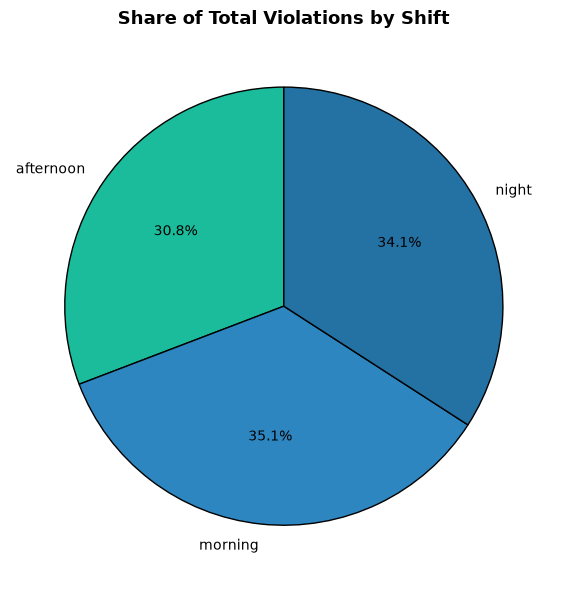

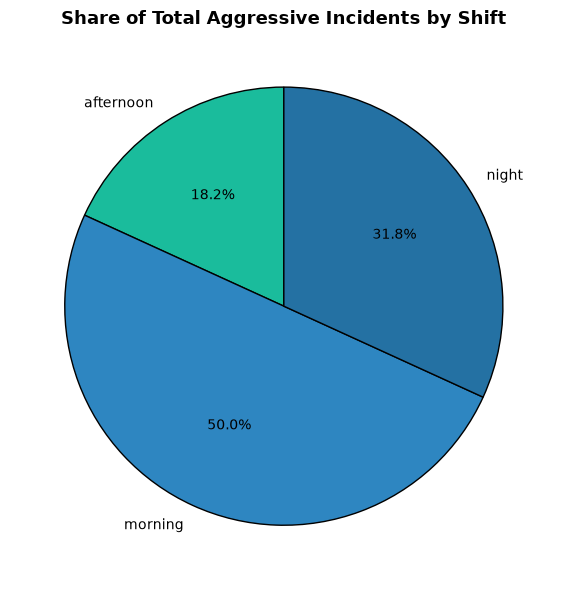

In [62]:
pie_metrics = {
    'total_violations' : 'Share of Total Violations by Shift',
    'total_aggressive_incidents' : 'Share of Total Aggressive Incidents by Shift'
}

for column, title_text in pie_metrics.items(): 
    labels = drivers_by_shift.index.tolist()
    sizes = drivers_by_shift[column].tolist()
    
    plt.figure(figsize=(6, 6))
    
    plt.pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",   
        startangle=90,  
        colors=colors,
        wedgeprops={"edgecolor": "black", "linewidth": 1},   
    )
    
    plt.title(title_text, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

In terms of the share by shift in total violations and aggressive incidents, total violations are **distributed almost equally** across all shifts. In contrast, aggressive incidents are **heavily concentrated in the morning shift**, which is half of all recorded events. The afternoon shift has the lowest share, while nighttime operations account for the remainder. This indicates that while standard traffic violations occur consistently throughout the day, aggressive driving behaviors are heavily influenced by morning-specific factors.

## Average Delays and Ratings by Shift

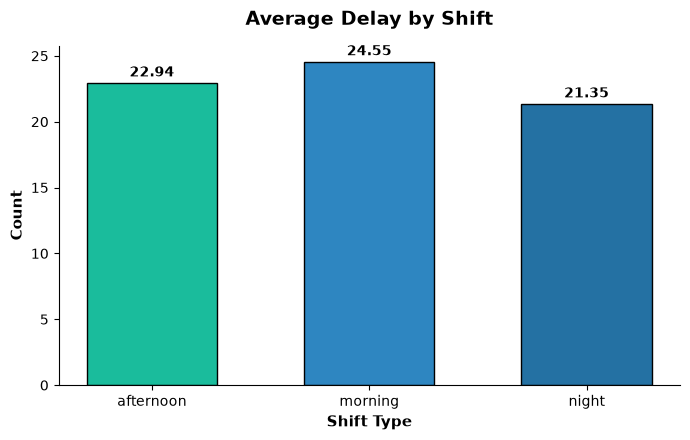

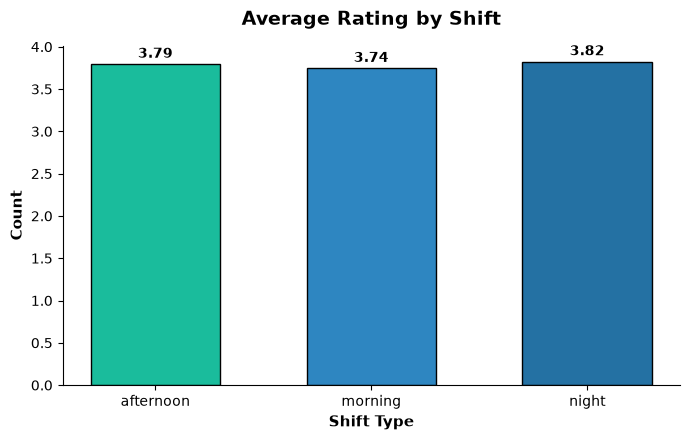

In [69]:
bar_metrics = {
    'avg_delay' : 'Average Delay by Shift', 
    'avg_rating' : 'Average Rating by Shift'
}

for column, title_text in bar_metrics.items():
    labels = drivers_by_shift.index.tolist()
    sizes = drivers_by_shift[column].tolist()

    plt.figure(figsize=(7, 4.5))

    bars = plt.bar(
        labels, sizes, color=colors, edgecolor="black", linewidth=1, width=0.6
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + (max(sizes) * 0.01), 
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    plt.title(title_text, fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Shift Type", fontsize=11, fontweight="700")
    plt.ylabel("Count", fontsize=11, fontweight="700")

    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

From the comparative analysis above, shift-level data indicates that both delivery delays and overall driver ratings remain consistent throughout the day. The minimal variance across shifts suggests that driver's work shift does not heavily impact their general performance.

## Save Datasets

In [77]:
EXPORT_DATA_PATH = '../data/metrics/'
df.to_csv(EXPORT_DATA_PATH + 'trips.csv', index=False)
weekly.reset_index()
weekly.to_csv(EXPORT_DATA_PATH + 'weekly_trips.csv', index=False)
driver_profile.reset_index()
driver_profile.to_csv(EXPORT_DATA_PATH + 'driver_profile.csv', index=False)
drivers_by_shift.reset_index()
drivers_by_shift.to_csv(EXPORT_DATA_PATH + 'drivers_by_shift.csv', index=False)